In [ ]:

import os, sys, time, csv, glob, random, math, itertools
import numpy as np
import SimpleITK as sitk


DATA_ROOT = r"C:\content\BRAIN2018\MICCAI_BraTS_2018_Data_Training"
PRE_ROOT  = r"C:\content\BRAIN2018\Preprocessed1"
MODS = ["flair","t1","t1ce","t2"]


LHS_SAMPLES = 12
REFINE_TOPK = 4
REFINE_TRIALS_PER_TOP = 4

FAST_ITERS  = [30, 20, 10]
FULL_ITERS_LIST = [[60,40,20],[50,30,20]]

SHRINK_SET = [3, 4]
CONV_THRESH_SET = [0.0, 1e-6, 5e-7]

LAMBDA_SMOOTH = 0.02
LAMBDA_RUNTIME = 0.0
RUNTIME_REF_SECONDS = 15.0

MASK_OTSU_BINS = 200
MIN_MASK_VOXELS = 5000  
MIN_CP_PER_DIM = 4 

_GRID_WARN_PRINTED = False  



def ensure_dir(p):
    if os.path.isfile(p):
        raise ValueError(f"Path exists and is a file: {p}")
    os.makedirs(p, exist_ok=True)

def nii_read(fp, t=sitk.sitkFloat32): return sitk.ReadImage(fp, t)
def nii_write(img, fp): ensure_dir(os.path.dirname(fp)); sitk.WriteImage(img, fp, True)

def modality_glob(subj_dir, mod):
    for p in [f"*_{mod}.nii", f"*_{mod}.nii.gz", f"*_{mod.upper()}.nii", f"*_{mod.upper()}.nii.gz"]:
        g = glob.glob(os.path.join(subj_dir, p))
        if g: return g[0]
    return None

def subject_modalities(subj_dir):
    d={}
    for m in MODS:
        fp = modality_glob(subj_dir, m)
        if fp: d[m]=fp
    return d

def pre_out_path(subj_dir, src_fp):
    base = os.path.basename(src_fp)
    if base.endswith(".nii.gz"):
        stem, ext = base[:-7], ".nii.gz"
    else:
        stem, ext = os.path.splitext(base)[0], ".nii"
    return os.path.join(PRE_ROOT, os.path.relpath(subj_dir, DATA_ROOT), f"{stem}_pre{ext}")


def build_mask_from_flair(flair_img):

    mask = sitk.OtsuThreshold(flair_img, 0, 1, MASK_OTSU_BINS)
    mask = sitk.Cast(mask, sitk.sitkUInt8)

    mask = sitk.BinaryMorphologicalClosing(mask, [1]*flair_img.GetDimension())
    mask = sitk.BinaryFillhole(mask)
    vox = int(sitk.GetArrayFromImage(mask).sum())
    if vox >= MIN_MASK_VOXELS:
        return mask, "otsu"


    nz = sitk.Cast(sitk.BinaryThreshold(flair_img, lowerThreshold=1e-6, upperThreshold=1e30, insideValue=1, outsideValue=0), sitk.sitkUInt8)
    nz = sitk.BinaryMorphologicalClosing(nz, [2]*flair_img.GetDimension())
    nz = sitk.BinaryFillhole(nz)
    if int(sitk.GetArrayFromImage(nz).sum()) >= MIN_MASK_VOXELS:
        return nz, "nonzero"

 
    cc = sitk.ConnectedComponent(nz)
    stats = sitk.LabelShapeStatisticsImageFilter()
    stats.Execute(cc)
    if stats.GetNumberOfLabels() > 0:
        sizes = [(stats.GetPhysicalSize(l), l) for l in stats.GetLabels()]
        _, lab = max(sizes)
        largest = sitk.Cast(sitk.BinaryThreshold(cc, lab, lab, 1, 0), sitk.sitkUInt8)
        if int(sitk.GetArrayFromImage(largest).sum()) >= MIN_MASK_VOXELS:
            return largest, "largest"

  
    whole = sitk.Cast(sitk.Image(flair_img.GetSize(), sitk.sitkUInt8)+1, sitk.sitkUInt8)
    whole.CopyInformation(flair_img)
    return whole, "whole"

    
def feasible_bspline_mm_range(mask_u8):

    spacing = mask_u8.GetSpacing()
    size    = mask_u8.GetSize()
    phys    = [size[i]*spacing[i] for i in range(3)]
    diam    = max(phys)


    center = max(100.0, min(180.0, 0.6*diam))

    lo = max(80.0, 0.6*center) 
    hi = min(200.0, 1.2*center)  


    min_extent = max(1.0, min(phys))
    hi_cap = min_extent / 3.0
    hi = min(hi, max(90.0, hi_cap))

    if hi < lo:

        mid = max(90.0, min(160.0, center))
        lo, hi = mid*0.9, mid*1.1

    return float(lo), float(hi)

def clamp_bspline_mm_to_feasible(b_mm, mask_u8):
    lo, hi = feasible_bspline_mm_range(mask_u8)
    b = float(max(lo, min(hi, b_mm)))
    return b, lo, hi


def set_bspline_grid(corrector, img_like, b_mm):

    global _GRID_WARN_PRINTED

    dim      = img_like.GetDimension()
    spacing  = img_like.GetSpacing()
    size     = img_like.GetSize()
    phys     = [size[i]*spacing[i] for i in range(dim)]
    order    = 3


    if hasattr(corrector, "SetSplineGridSpacingInPhysicalSpace"):
        try:
            corrector.SetSplineGridSpacingInPhysicalSpace([float(b_mm)]*dim)
            return "spacing_mm"
        except Exception:
            pass


    grid_n = [max(4, int(round(phys[i]/max(1.0, b_mm))) + order) for i in range(dim)]
    if hasattr(corrector, "SetSplineGridSize"):
        try:
            corrector.SetSplineGridSize(grid_n)
            return "grid_size"
        except Exception:
            pass


    if hasattr(corrector, "SetSplineDistance"):
        try:
            corrector.SetSplineDistance(float(b_mm))
            return "spline_distance"
        except Exception:
            pass


    if hasattr(corrector, "SetNumberOfControlPoints"):
        try:
            corrector.SetNumberOfControlPoints(grid_n)
            return "num_ctrl_pts"
        except Exception:
            pass


    if not _GRID_WARN_PRINTED:
        print("[WARN] Could not set N4 B-spline grid via any known API; using SimpleITK defaults.", flush=True)
        _GRID_WARN_PRINTED = True
    return "default"



def cv_mean_std(img, mask):
    arr = sitk.GetArrayFromImage(img)
    msk = sitk.GetArrayFromImage(mask).astype(bool)
    vox = arr[msk]
    if vox.size < 10: return (float("inf"), float("nan"), float("nan"))
    mean = float(np.mean(vox)); std = float(np.std(vox))
    return float(std/(mean+1e-8)), mean, std

def robust_score(corrected, mask, log_field, elapsed_sec=0.0):
    arr = sitk.GetArrayFromImage(corrected)
    msk = sitk.GetArrayFromImage(mask).astype(bool)
    vox = arr[msk]
    if vox.size < 10: return float("inf"), float("nan"), float("nan"), float("nan")
    med = float(np.median(vox))
    mad = float(np.median(np.abs(vox-med))) * 1.4826
    rcv = mad/(med+1e-8)
    lf = sitk.GetArrayFromImage(log_field)
    gx,gy,gz = np.gradient(lf)
    smooth = float(np.sqrt((gx**2+gy**2+gz**2).mean()))
    rt = float(elapsed_sec/max(1e-6,RUNTIME_REF_SECONDS))
    score = rcv + LAMBDA_SMOOTH*smooth + LAMBDA_RUNTIME*rt
    return score, rcv, smooth, rt


def n4_correct(img_f32, mask_u8, bspline_mm, shrink, iters, conv_thresh):

    eps = 1e-6
    img_pos = sitk.Clamp(img_f32, lowerBound=eps, upperBound=float("inf"))


    shrink = int(shrink)
    img_exec  = img_pos  if shrink <= 1 else sitk.Shrink(img_pos,  [shrink]*img_pos.GetDimension())
    mask_exec = mask_u8  if shrink <= 1 else sitk.Shrink(mask_u8,  [shrink]*mask_u8.GetDimension())


    b_clamped, lo, hi = clamp_bspline_mm_to_feasible(bspline_mm, mask_u8)

    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrector.SetSplineOrder(3) 
    corrector.SetMaximumNumberOfIterations([int(x) for x in iters])
    corrector.SetConvergenceThreshold(float(conv_thresh))


    _ = set_bspline_grid(corrector, img_exec, b_clamped)


    t0 = time.time()
    _ = corrector.Execute(img_exec, mask_exec)
    elapsed = time.time() - t0


    log_field_full = corrector.GetLogBiasFieldAsImage(img_pos)
    corrected_full = img_pos / sitk.Exp(log_field_full)

    return corrected_full, log_field_full, elapsed, b_clamped



def lhs_uniform(n, d):
    rng=np.random.default_rng()
    res=np.zeros((n,d),float); cut=np.linspace(0,1,n+1)
    for j in range(d):
        u=rng.random(n); pts = cut[:n] + (cut[1:]-cut[:n])*u; rng.shuffle(pts); res[:,j]=pts
    return res

def coarse_candidates_LHS(n, b_lo, b_hi):
    X = lhs_uniform(n, 1)
    cands=[]
    for i in range(n):
        b = b_lo + (b_hi-b_lo)*float(X[i,0])
        s = random.choice(SHRINK_SET)
        eps = random.choice(CONV_THRESH_SET)
        cands.append((b,s,FAST_ITERS,eps))
    return cands

def neighborhood_candidates(best_list, b_lo, b_hi, trials_per_top):
    cands=[]; deltas=[-30,-20,-10,10,20,30]
    for (b0,s0,_i0,eps0) in best_list:
        b_pert = sorted(set([round(max(b_lo,min(b_hi,b0+d)),2) for d in deltas]+[round(b0,2)]))
        for _ in range(trials_per_top):
            b = random.choice(b_pert); s = random.choice(SHRINK_SET)
            eps = random.choice(CONV_THRESH_SET); iters = random.choice(FULL_ITERS_LIST)
            cands.append((b,s,iters,eps))
        for iters in FULL_ITERS_LIST:
            cands.append((b0,s0,iters,eps0))
    # dedup
    uniq=[]; seen=set()
    for c in cands:
        key=(round(c[0],2),int(c[1]),tuple(c[2]),float(c[3]))
        if key not in seen: uniq.append(c); seen.add(key)
    return uniq


def evaluate_candidate(img, mask, cand, subj_name, mod, idx=None):
    b,s,iters,eps = cand
    try:
        corrected, logf, elapsed, b_used = n4_correct(img, mask, b, s, iters, eps)
        score, rcv, smooth, rt = robust_score(corrected, mask, logf, elapsed)
        return {
            "ok": True,
            "params": (float(b_used),int(s),list(map(int,iters)),float(eps)),
            "score": float(score), "rcv": float(rcv), "smooth": float(smooth), "rt": float(rt),
            "corrected": corrected, "logf": logf, "elapsed": float(elapsed)
        }
    except Exception as e:
        print(f"[CAND-ERROR] {subj_name} {mod.upper()} cand#{idx or '?'} "
              f"b={b:.1f} s={s} iters={iters} eps={eps} :: {e}", flush=True)
        return {"ok": False, "err": str(e)}

def tune_modality(img, mask, subj_name, mod, prior_best=None):

    mask_built, mask_mode = build_mask_from_flair(img) if mod=="flair" else (mask, "reused")
    mvox = int(sitk.GetArrayFromImage(mask_built).sum())
    print(f"[{subj_name}] {mod.upper()} mask mode = {mask_mode} | voxels = {mvox}", flush=True)


    b_lo, b_hi = feasible_bspline_mm_range(mask_built)
    print(f"[{subj_name}] {mod.upper()} feasible spacing ~ [{b_lo:.1f}, {b_hi:.1f}] mm", flush=True)


    coarse = coarse_candidates_LHS(LHS_SAMPLES, b_lo, b_hi)
    if prior_best is not None:
        b0,s0,_i0,eps0 = prior_best

        b0c, _, _ = clamp_bspline_mm_to_feasible(b0, mask_built)
        coarse += [(b0c,s0,FAST_ITERS,eps0),
                   (max(b_lo,b0c-20),s0,FAST_ITERS,eps0),
                   (min(b_hi,b0c+20),s0,FAST_ITERS,eps0)]
    coarse_res=[]
    for i,c in enumerate(coarse,1):
        r = evaluate_candidate(img, mask_built, c, subj_name, mod, idx=i)
        if r["ok"]: coarse_res.append(r)
    if not coarse_res:
        raise RuntimeError("Coarse search failed: all candidates invalid (see CAND-ERROR lines).")

    coarse_res.sort(key=lambda x:x["score"])
    topK = coarse_res[:max(1,REFINE_TOPK)]
    top_params = [tuple(x["params"]) for x in topK]

 
    neigh = neighborhood_candidates(top_params, b_lo, b_hi, REFINE_TRIALS_PER_TOP)
    best = None
    for i,c in enumerate(neigh,1):
        r = evaluate_candidate(img, mask_built, c, subj_name, mod, idx=f"R{i}")
        if r["ok"] and (best is None or r["score"] < best["score"]):
            best = r
    if best is None:

        best = topK[0]
    return best, mask_built


def cv_block(img, mask): 
    cv, mean, std = cv_mean_std(img, mask); return cv, mean, std

def find_subject_dirs():
    dirs=[]
    for grade in ["HGG","LGG"]:
        root=os.path.join(DATA_ROOT,grade)
        if not os.path.isdir(root): continue
        for d in sorted(os.listdir(root)):
            p=os.path.join(root,d)
            if os.path.isdir(p) and glob.glob(os.path.join(p,"*_flair.nii*")):
                dirs.append(p)
    return dirs

def run():
    print("[INFO] DATA_ROOT:", DATA_ROOT)
    print("[INFO] PRE_ROOT :", PRE_ROOT)
    ensure_dir(PRE_ROOT)
    subjects = find_subject_dirs()
    print(f"[INFO] Subjects found: {len(subjects)}")
    if not subjects:
        print(" No subjects found."); return

    csv_fp = os.path.join(PRE_ROOT, "n4_autotune_report.csv")
    rows=[]; t0=time.time()

    for si, subj_dir in enumerate(subjects,1):
        subj = os.path.basename(subj_dir)
        print(f"\n[SUBJECT-START] {subj}", flush=True)
        mod_fps = subject_modalities(subj_dir)
        if "flair" not in mod_fps:
            print(f"[WARN] {subj}: missing FLAIR → skip"); continue


        flair_img = nii_read(mod_fps["flair"], sitk.sitkFloat32)
        best_flair, mask = tune_modality(flair_img, None, subj, "flair", prior_best=None)
        b_mm,s,iters,eps = best_flair["params"]
        out_fp = pre_out_path(subj_dir, mod_fps["flair"])
        nii_write(best_flair["corrected"], out_fp)
        raw_cv, raw_mean, raw_std = cv_block(flair_img, mask)
        cor_cv, cor_mean, cor_std = cv_block(best_flair["corrected"], mask)
        row = dict(subject=subj, modality="flair",
                   raw_mean=raw_mean, raw_std=raw_std, raw_cv=raw_cv,
                   cor_mean=cor_mean, cor_std=cor_std, cor_cv=cor_cv,
                   improved=bool(cor_cv<raw_cv), bspline_mm=b_mm, shrink=s,
                   iters=str(iters), conv_thresh=eps,
                   score=float(best_flair["score"]), rcv=float(best_flair["rcv"]),
                   smooth=float(best_flair["smooth"]), rt=float(best_flair["rt"]),
                   seconds=float(best_flair["elapsed"]), output_path=out_fp)
        print("[RESULT]", row, flush=True)
        rows.append(row)
        prior = (b_mm,s,iters,eps)


        for mod in [m for m in MODS if m in mod_fps and m!="flair"]:
            img = nii_read(mod_fps[mod], sitk.sitkFloat32)
            best, _ = tune_modality(img, mask, subj, mod, prior_best=prior)
            out_fp = pre_out_path(subj_dir, mod_fps[mod])
            nii_write(best["corrected"], out_fp)
            raw_cv, raw_mean, raw_std = cv_block(img, mask)
            cor_cv, cor_mean, cor_std = cv_block(best["corrected"], mask)
            row = dict(subject=subj, modality=mod,
                       raw_mean=raw_mean, raw_std=raw_std, raw_cv=raw_cv,
                       cor_mean=cor_mean, cor_std=cor_std, cor_cv=cor_cv,
                       improved=bool(cor_cv<raw_cv),
                       bspline_mm=float(best["params"][0]), shrink=int(best["params"][1]),
                       iters=str(best["params"][2]), conv_thresh=float(best["params"][3]),
                       score=float(best["score"]), rcv=float(best["rcv"]),
                       smooth=float(best["smooth"]), rt=float(best["rt"]),
                       seconds=float(best["elapsed"]), output_path=out_fp)
            print("[RESULT]", row, flush=True)
            rows.append(row)
            prior = best["params"]

        print(f"[SUBJECT-DONE] {subj} | scans={len([r for r in rows if r['subject']==subj])}", flush=True)


    with open(csv_fp, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=[
            "subject","modality",
            "raw_mean","raw_std","raw_cv",
            "cor_mean","cor_std","cor_cv",
            "improved","bspline_mm","shrink","iters","conv_thresh",
            "score","rcv","smooth","rt","seconds","output_path"
        ])
        w.writeheader()
        for r in rows: w.writerow(r)

    improved = sum(1 for r in rows if r["improved"])
    print("\n================ RUN SUMMARY ================")
    print(f"[DONE] Corrected {len(rows)} volumes | CV improved in {improved}/{len(rows)}.")
    print(f"[REPORT] {csv_fp}")
    print(f"[WALL-TIME] {(time.time()-t0)/60.2:.2f} minutes")
    print("=============================================")

run()


[INFO] DATA_ROOT: C:\content\BRAIN2018\MICCAI_BraTS_2018_Data_Training
[INFO] PRE_ROOT : C:\content\BRAIN2018\Preprocessed1
[INFO] Subjects found: 360

[SUBJECT-START] Brats18_2013_0_1
[Brats18_2013_0_1] FLAIR mask mode = otsu | voxels = 946887
[Brats18_2013_0_1] FLAIR feasible spacing ~ [86.4, 90.0] mm
[RESULT] {'subject': 'Brats18_2013_0_1', 'modality': 'flair', 'raw_mean': 318.527587890625, 'raw_std': 72.14885711669922, 'raw_cv': 0.2265074042478493, 'cor_mean': 352.32086772349817, 'cor_std': 70.77133235801612, 'cor_cv': 0.2008718155506725, 'improved': True, 'bspline_mm': 90.0, 'shrink': 3, 'iters': '[60, 40, 20]', 'conv_thresh': 0.0, 'score': 0.10164008980963264, 'rcv': 0.10156786519914751, 'smooth': 0.0036112305242568254, 'rt': 0.6915774186452229, 'seconds': 10.373661279678345, 'output_path': 'C:\\content\\BRAIN2018\\Preprocessed1\\HGG\\Brats18_2013_0_1\\Brats18_2013_0_1_flair_pre.nii'}
[Brats18_2013_0_1] T1 mask mode = reused | voxels = 946887
[Brats18_2013_0_1] T1 feasible spacin

In [ ]:
import os, glob, shutil


PRE_ROOT = r"C:\content\BRAIN2018\AutoTuned_N4_Brats2018"


RAW_ROOT = r"C:\content\BRAIN2018\MICCAI_BraTS_2018_Data_Training"

count = 0
missing = []

for grade in ["HGG", "LGG"]:
    raw_grade_dir = os.path.join(RAW_ROOT, grade)
    pre_grade_dir = os.path.join(PRE_ROOT, grade)
    if not os.path.isdir(raw_grade_dir):
        continue

    for subj in sorted(os.listdir(raw_grade_dir)):
        raw_subj_dir = os.path.join(raw_grade_dir, subj)
        pre_subj_dir = os.path.join(pre_grade_dir, subj)
        if not os.path.isdir(pre_subj_dir):
            continue


        seg_src = None
        for p in ["*_seg.nii", "*_seg.nii.gz"]:
            g = glob.glob(os.path.join(raw_subj_dir, p))
            if g:
                seg_src = g[0]
                break

        if not seg_src:
            missing.append(subj)
            continue


        base = os.path.basename(seg_src)
        if base.endswith(".nii.gz"):
            seg_dst = os.path.join(pre_subj_dir, base[:-7] + "_pre.nii.gz")
        else:
            seg_dst = os.path.join(pre_subj_dir, base[:-4] + "_pre.nii")


        shutil.copy(seg_src, seg_dst)
        count += 1
        print(f"[COPY] {subj} → {os.path.basename(seg_dst)}")

print("\n✅ Done.")
print(f"Copied {count} segmentation files to preprocessed folders.")
if missing:
    print(f" Missing segmentations for: {missing}")


[COPY] Brats18_2013_10_1 → Brats18_2013_10_1_seg_pre.nii
[COPY] Brats18_2013_11_1 → Brats18_2013_11_1_seg_pre.nii
[COPY] Brats18_2013_12_1 → Brats18_2013_12_1_seg_pre.nii
[COPY] Brats18_2013_13_1 → Brats18_2013_13_1_seg_pre.nii
[COPY] Brats18_2013_14_1 → Brats18_2013_14_1_seg_pre.nii
[COPY] Brats18_2013_17_1 → Brats18_2013_17_1_seg_pre.nii
[COPY] Brats18_2013_18_1 → Brats18_2013_18_1_seg_pre.nii
[COPY] Brats18_2013_19_1 → Brats18_2013_19_1_seg_pre.nii
[COPY] Brats18_2013_20_1 → Brats18_2013_20_1_seg_pre.nii
[COPY] Brats18_2013_21_1 → Brats18_2013_21_1_seg_pre.nii
[COPY] Brats18_2013_22_1 → Brats18_2013_22_1_seg_pre.nii
[COPY] Brats18_2013_23_1 → Brats18_2013_23_1_seg_pre.nii
[COPY] Brats18_2013_25_1 → Brats18_2013_25_1_seg_pre.nii
[COPY] Brats18_2013_26_1 → Brats18_2013_26_1_seg_pre.nii
[COPY] Brats18_2013_27_1 → Brats18_2013_27_1_seg_pre.nii
[COPY] Brats18_2013_2_1 → Brats18_2013_2_1_seg_pre.nii
[COPY] Brats18_2013_3_1 → Brats18_2013_3_1_seg_pre.nii
[COPY] Brats18_2013_4_1 → Brats18_2

In [8]:

import os, glob
import numpy as np
import SimpleITK as sitk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


DATA_ROOT = r"C:\content\BRAIN2018\MICCAI_BraTS_2018_Data_Training"
PRE_ROOT  = r"C:\content\BRAIN2018\AutoTuned_N4_Brats2018"
CSV_PATH  = os.path.join(PRE_ROOT, "evaluation_report.csv")
VIZ_DIR   = os.path.join(PRE_ROOT, "visualizations")
os.makedirs(VIZ_DIR, exist_ok=True)

MODS = ["flair", "t1", "t1ce", "t2"]

print("✅ Configuration loaded.")
print(f"   DATA_ROOT : {DATA_ROOT}")
print(f"   PRE_ROOT  : {PRE_ROOT}")
print(f"   VIZ_DIR   : {VIZ_DIR}")



def find_subject_pairs():
    """
    For each subject, find the original and preprocessed
    modality files. Returns a list of dicts.
    """
    pairs = []

    for grade in ["HGG", "LGG"]:
        raw_grade = os.path.join(DATA_ROOT, grade)
        pre_grade = os.path.join(PRE_ROOT,  grade)

        if not os.path.isdir(raw_grade):
            print(f"[WARN] Missing: {raw_grade}")
            continue

        for subj in sorted(os.listdir(raw_grade)):
            raw_subj = os.path.join(raw_grade, subj)
            pre_subj = os.path.join(pre_grade, subj)

            if not os.path.isdir(raw_subj):
                continue
            if not os.path.isdir(pre_subj):
                print(f"[WARN] No preprocessed folder for {subj} → skip")
                continue

            for mod in MODS:
                # --- raw file ---
                raw_fp = None
                for pattern in [f"*_{mod}.nii.gz", f"*_{mod}.nii"]:
                    hits = glob.glob(os.path.join(raw_subj, pattern))
                    if hits:
                        raw_fp = hits[0]
                        break


                pre_fp = None
                for pattern in [f"*_{mod}_pre.nii.gz", f"*_{mod}_pre.nii"]:
                    hits = glob.glob(os.path.join(pre_subj, pattern))
                    if hits:
                        pre_fp = hits[0]
                        break

                if raw_fp and pre_fp:
                    pairs.append({
                        "subject"  : subj,
                        "grade"    : grade,
                        "modality" : mod,
                        "raw_fp"   : raw_fp,
                        "pre_fp"   : pre_fp,
                    })
                else:
                    if not raw_fp:
                        print(f"[WARN] {subj} {mod}: missing raw file")
                    if not pre_fp:
                        print(f"[WARN] {subj} {mod}: missing preprocessed file")

    print(f"\n✅ Found {len(pairs)} subject-modality pairs.")
    return pairs


pairs = find_subject_pairs()

✅ Configuration loaded.
   DATA_ROOT : C:\content\BRAIN2018\MICCAI_BraTS_2018_Data_Training
   PRE_ROOT  : C:\content\BRAIN2018\AutoTuned_N4_Brats2018
   VIZ_DIR   : C:\content\BRAIN2018\AutoTuned_N4_Brats2018\visualizations

✅ Found 1140 subject-modality pairs.


In [9]:


def build_brain_mask(img_sitk, otsu_bins=200, min_voxels=5000):

    # 1) Otsu
    mask = sitk.OtsuThreshold(img_sitk, 0, 1, otsu_bins)
    mask = sitk.Cast(mask, sitk.sitkUInt8)
    mask = sitk.BinaryMorphologicalClosing(mask, [1] * img_sitk.GetDimension())
    mask = sitk.BinaryFillhole(mask)
    if int(sitk.GetArrayFromImage(mask).sum()) >= min_voxels:
        return mask, "otsu"

    # 2) Nonzero
    nz = sitk.Cast(
        sitk.BinaryThreshold(img_sitk, 1e-6, 1e30, 1, 0),
        sitk.sitkUInt8
    )
    nz = sitk.BinaryMorphologicalClosing(nz, [2] * img_sitk.GetDimension())
    nz = sitk.BinaryFillhole(nz)
    if int(sitk.GetArrayFromImage(nz).sum()) >= min_voxels:
        return nz, "nonzero"

    # 3) Whole image fallback
    whole = sitk.Cast(
        sitk.Image(img_sitk.GetSize(), sitk.sitkUInt8) + 1,
        sitk.sitkUInt8
    )
    whole.CopyInformation(img_sitk)
    return whole, "whole"

print("Mask builder defined.")



def get_brain_voxels(img_sitk, mask_sitk):
    arr = sitk.GetArrayFromImage(img_sitk)
    msk = sitk.GetArrayFromImage(mask_sitk).astype(bool)
    return arr[msk]


def compute_cv(vox):

    if vox.size < 10:
        return float("nan")
    return float(np.std(vox) / (np.mean(vox) + 1e-8))


def compute_rcv(vox):

    if vox.size < 10:
        return float("nan")
    med = np.median(vox)
    mad = np.median(np.abs(vox - med)) * 1.4826
    return float(mad / (med + 1e-8))


def compute_snr(vox):

    if vox.size < 10:
        return float("nan")
    return float(np.mean(vox) / (np.std(vox) + 1e-8))


def compute_cnr(vox):

    if vox.size < 20:
        return float("nan")
    threshold = np.percentile(vox, 65)
    wm = vox[vox >= threshold]
    gm = vox[vox <  threshold]
    if len(wm) < 10 or len(gm) < 10:
        return float("nan")
    cnr = abs(np.mean(wm) - np.mean(gm)) / (
        np.sqrt((np.std(wm)**2 + np.std(gm)**2) / 2) + 1e-8
    )
    return float(cnr)


def compute_iu(vox):

    if vox.size < 10:
        return float("nan")
    return float(1.0 - np.std(vox) / (np.mean(vox) + 1e-8))


def compute_all_metrics(img_sitk, mask_sitk):

    vox = get_brain_voxels(img_sitk, mask_sitk)
    return {
        "mean" : float(np.mean(vox))   if vox.size >= 10 else float("nan"),
        "std"  : float(np.std(vox))    if vox.size >= 10 else float("nan"),
        "cv"   : compute_cv(vox),
        "rcv"  : compute_rcv(vox),
        "snr"  : compute_snr(vox),
        "cnr"  : compute_cnr(vox),
        "iu"   : compute_iu(vox),
    }

print("Metric functions defined.")

Mask builder defined.
Metric functions defined.


In [10]:


rows = []
total = len(pairs)

for i, p in enumerate(pairs, 1):
    try:

        raw_img = sitk.ReadImage(p["raw_fp"], sitk.sitkFloat32)
        pre_img = sitk.ReadImage(p["pre_fp"], sitk.sitkFloat32)


        mask, mask_mode = build_brain_mask(raw_img)


        raw_m = compute_all_metrics(raw_img, mask)
        pre_m = compute_all_metrics(pre_img, mask)

        row = {
            "subject"      : p["subject"],
            "grade"        : p["grade"],
            "modality"     : p["modality"],
            "mask_mode"    : mask_mode,


            "raw_mean"     : raw_m["mean"],
            "raw_std"      : raw_m["std"],
            "raw_cv"       : raw_m["cv"],
            "raw_rcv"      : raw_m["rcv"],
            "raw_snr"      : raw_m["snr"],
            "raw_cnr"      : raw_m["cnr"],
            "raw_iu"       : raw_m["iu"],


            "pre_mean"     : pre_m["mean"],
            "pre_std"      : pre_m["std"],
            "pre_cv"       : pre_m["cv"],
            "pre_rcv"      : pre_m["rcv"],
            "pre_snr"      : pre_m["snr"],
            "pre_cnr"      : pre_m["cnr"],
            "pre_iu"       : pre_m["iu"],

 
            "cv_improved"  : bool(pre_m["cv"]  < raw_m["cv"]),
            "snr_improved" : bool(pre_m["snr"] > raw_m["snr"]),
            "cnr_improved" : bool(pre_m["cnr"] > raw_m["cnr"]),
            "iu_improved"  : bool(pre_m["iu"]  > raw_m["iu"]),
        }
        rows.append(row)

        if i % 50 == 0 or i == total:
            print(f"Progress: {i}/{total} | "
                  f"{p['subject']} {p['modality'].upper()} | "
                  f"CV: {raw_m['cv']:.4f}→{pre_m['cv']:.4f} | "
                  f"SNR: {raw_m['snr']:.3f}→{pre_m['snr']:.3f}",
                  flush=True)

    except Exception as e:
        print(f"[ERROR] {p['subject']} {p['modality']}: {e}")
        continue


df = pd.DataFrame(rows)


df["cv_reduction_pct"]  = (df["raw_cv"]  - df["pre_cv"])  / (df["raw_cv"]  + 1e-8) * 100
df["snr_gain_pct"]      = (df["pre_snr"] - df["raw_snr"]) / (df["raw_snr"] + 1e-8) * 100
df["cnr_gain_pct"]      = (df["pre_cnr"] - df["raw_cnr"]) / (df["raw_cnr"] + 1e-8) * 100
df["iu_gain_pct"]       = (df["pre_iu"]  - df["raw_iu"])  / (df["raw_iu"]  + 1e-8) * 100

df.to_csv(CSV_PATH, index=False)
print(f"\n Evaluation complete. {len(df)} rows saved to:\n   {CSV_PATH}")

Progress: 50/1140 | Brats18_2013_25_1 T1 | CV: 0.2052→0.1730 | SNR: 4.873→5.779
Progress: 100/1140 | Brats18_CBICA_ABB_1 T2 | CV: 0.4222→0.4050 | SNR: 2.368→2.469
Progress: 150/1140 | Brats18_CBICA_ANP_1 T1 | CV: 0.2412→0.2093 | SNR: 4.146→4.777
Progress: 200/1140 | Brats18_CBICA_AQG_1 T2 | CV: 0.3859→0.3596 | SNR: 2.592→2.781
Progress: 250/1140 | Brats18_CBICA_ARW_1 T1 | CV: 0.2297→0.1876 | SNR: 4.353→5.331
Progress: 300/1140 | Brats18_CBICA_ASY_1 T2 | CV: 0.5392→0.5372 | SNR: 1.855→1.861
Progress: 350/1140 | Brats18_CBICA_AWG_1 T1 | CV: 0.2390→0.2023 | SNR: 4.184→4.944
Progress: 400/1140 | Brats18_CBICA_AYU_1 T2 | CV: 0.4564→0.4256 | SNR: 2.191→2.350
Progress: 450/1140 | Brats18_TCIA01_186_1 T1 | CV: 0.1769→0.1189 | SNR: 5.654→8.411
Progress: 500/1140 | Brats18_TCIA01_412_1 T2 | CV: 0.3169→0.2456 | SNR: 3.156→4.072
Progress: 550/1140 | Brats18_TCIA02_198_1 T1 | CV: 0.3391→0.2497 | SNR: 2.949→4.004
Progress: 600/1140 | Brats18_TCIA02_331_1 T2 | CV: 0.3609→0.3393 | SNR: 2.771→2.947
Pro

In [11]:


print("=" * 65)
print("MEAN METRICS BEFORE vs AFTER — ALL MODALITIES")
print("=" * 65)

summary = df.groupby("modality").agg(
    raw_cv  =("raw_cv",  "mean"),
    pre_cv  =("pre_cv",  "mean"),
    raw_snr =("raw_snr", "mean"),
    pre_snr =("pre_snr", "mean"),
    raw_cnr =("raw_cnr", "mean"),
    pre_cnr =("pre_cnr", "mean"),
    raw_iu  =("raw_iu",  "mean"),
    pre_iu  =("pre_iu",  "mean"),
    cv_red_pct  =("cv_reduction_pct", "mean"),
    snr_gain_pct=("snr_gain_pct",     "mean"),
    pct_cv_improved =("cv_improved",  "mean"),
    pct_snr_improved=("snr_improved", "mean"),
).round(4)

summary["pct_cv_improved"]  = (summary["pct_cv_improved"]  * 100).round(1)
summary["pct_snr_improved"] = (summary["pct_snr_improved"] * 100).round(1)

print(summary.to_string())
summary.to_csv(os.path.join(VIZ_DIR, "summary_table.csv"))
print(f"\n✅ Summary saved.")

MEAN METRICS BEFORE vs AFTER — ALL MODALITIES
          raw_cv  pre_cv  raw_snr  pre_snr  raw_cnr  pre_cnr  raw_iu  pre_iu  cv_red_pct  snr_gain_pct  pct_cv_improved  pct_snr_improved
modality                                                                                                                                 
flair     0.2927  0.2266   3.6514   4.6868   1.8923   1.7940  0.7073  0.7734     21.5883       30.1138            100.0             100.0
t1        0.2169  0.1771   4.7825   5.9068   2.3972   1.8925  0.7831  0.8229     18.3111       23.5773             99.3              99.3
t1ce      0.2543  0.2242   4.1876   4.8959   1.8644   1.4621  0.7457  0.7758     12.5103       15.8553             96.5              96.5
t2        0.3681  0.3261   2.8711   3.3531   2.2022   2.0371  0.6319  0.6739     12.2909       15.3485             98.6              98.6

✅ Summary saved.


In [12]:


print("=" * 65)
print("WILCOXON SIGNED-RANK TESTS")
print("=" * 65)

metric_pairs = [
    ("raw_cv",  "pre_cv",  "CV",  "↓ lower is better"),
    ("raw_rcv", "pre_rcv", "rCV", "↓ lower is better"),
    ("raw_snr", "pre_snr", "SNR", "↑ higher is better"),
    ("raw_cnr", "pre_cnr", "CNR", "↑ higher is better"),
    ("raw_iu",  "pre_iu",  "IU",  "↑ higher is better"),
]

for mod in MODS:
    sub = df[df["modality"] == mod].dropna()
    print(f"\n--- {mod.upper()} (n={len(sub)}) ---")
    for raw_col, pre_col, label, direction in metric_pairs:
        raw_v = sub[raw_col].values
        pre_v = sub[pre_col].values
        if len(raw_v) < 5:
            continue
        stat, p = stats.wilcoxon(raw_v, pre_v)
        delta   = np.mean(pre_v) - np.mean(raw_v)
        sig     = ("***" if p < 0.001 else
                   "**"  if p < 0.01  else
                   "*"   if p < 0.05  else "ns")
        print(f"  {label:4s} {direction:20s} | "
              f"{np.mean(raw_v):.4f} → {np.mean(pre_v):.4f} "
              f"| Δ={delta:+.4f} | p={p:.2e} {sig}")

WILCOXON SIGNED-RANK TESTS

--- FLAIR (n=285) ---
  CV   ↓ lower is better    | 0.2927 → 0.2266 | Δ=-0.0661 | p=1.73e-48 ***
  rCV  ↓ lower is better    | 0.1874 → 0.1415 | Δ=-0.0459 | p=1.73e-48 ***
  SNR  ↑ higher is better   | 3.6514 → 4.6868 | Δ=+1.0354 | p=1.73e-48 ***
  CNR  ↑ higher is better   | 1.8923 → 1.7940 | Δ=-0.0984 | p=2.63e-09 ***
  IU   ↑ higher is better   | 0.7073 → 0.7734 | Δ=+0.0661 | p=1.73e-48 ***

--- T1 (n=285) ---
  CV   ↓ lower is better    | 0.2169 → 0.1771 | Δ=-0.0398 | p=4.59e-47 ***
  rCV  ↓ lower is better    | 0.2025 → 0.1278 | Δ=-0.0747 | p=3.33e-47 ***
  SNR  ↑ higher is better   | 4.7825 → 5.9068 | Δ=+1.1242 | p=4.05e-47 ***
  CNR  ↑ higher is better   | 2.3972 → 1.8925 | Δ=-0.5047 | p=2.25e-48 ***
  IU   ↑ higher is better   | 0.7831 → 0.8229 | Δ=+0.0398 | p=4.59e-47 ***

--- T1CE (n=285) ---
  CV   ↓ lower is better    | 0.2543 → 0.2242 | Δ=-0.0301 | p=1.06e-45 ***
  rCV  ↓ lower is better    | 0.1894 → 0.1199 | Δ=-0.0695 | p=2.15e-47 ***
  SNR  ↑

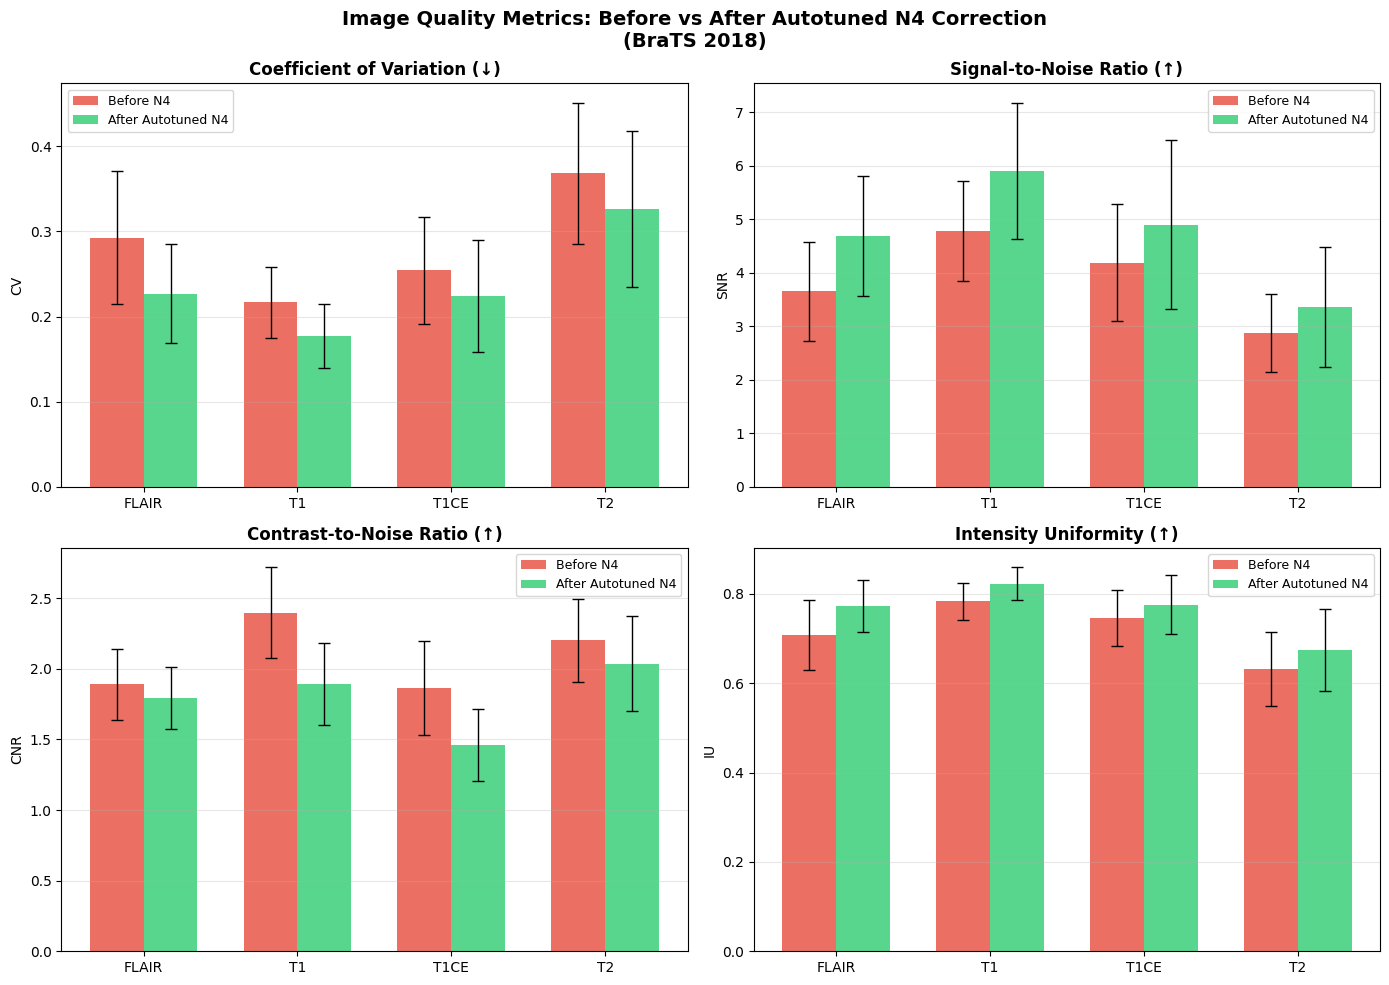

✅ Saved: chart1_grouped_bar.png


In [13]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes  = axes.flatten()
x     = np.arange(len(MODS))
width = 0.35

metrics_config = [
    ("raw_cv",  "pre_cv",  "CV",  "Coefficient of Variation (↓)"),
    ("raw_snr", "pre_snr", "SNR", "Signal-to-Noise Ratio (↑)"),
    ("raw_cnr", "pre_cnr", "CNR", "Contrast-to-Noise Ratio (↑)"),
    ("raw_iu",  "pre_iu",  "IU",  "Intensity Uniformity (↑)"),
]

for idx, (raw_col, pre_col, ylabel, title) in enumerate(metrics_config):
    ax = axes[idx]

    raw_means = [df[df["modality"]==m][raw_col].mean() for m in MODS]
    pre_means = [df[df["modality"]==m][pre_col].mean() for m in MODS]
    raw_stds  = [df[df["modality"]==m][raw_col].std()  for m in MODS]
    pre_stds  = [df[df["modality"]==m][pre_col].std()  for m in MODS]

    ax.bar(x - width/2, raw_means, width, yerr=raw_stds,
           label="Before N4", color="#E74C3C", alpha=0.8,
           capsize=4, error_kw={"linewidth":1})
    ax.bar(x + width/2, pre_means, width, yerr=pre_stds,
           label="After Autotuned N4", color="#2ECC71", alpha=0.8,
           capsize=4, error_kw={"linewidth":1})

    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in MODS])
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Image Quality Metrics: Before vs After Autotuned N4 Correction\n(BraTS 2018)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "chart1_grouped_bar.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chart1_grouped_bar.png")

In [19]:


print("=" * 65)
print("FINAL EVALUATION SUMMARY — BraTS 2018")
print("=" * 65)
print(f"Total volumes evaluated : {len(df)}")
print(f"Subjects                : {df['subject'].nunique()}")
print(f"HGG subjects            : {df[df['grade']=='HGG']['subject'].nunique()}")
print(f"LGG subjects            : {df[df['grade']=='LGG']['subject'].nunique()}")
print()
print(f"CV  improved in : {df['cv_improved'].sum()}/{len(df)} "
      f"({df['cv_improved'].mean()*100:.1f}%)")
print(f"SNR improved in : {df['snr_improved'].sum()}/{len(df)} "
      f"({df['snr_improved'].mean()*100:.1f}%)")
print(f"CNR improved in : {df['cnr_improved'].sum()}/{len(df)} "
      f"({df['cnr_improved'].mean()*100:.1f}%)")
print(f"IU  improved in : {df['iu_improved'].sum()}/{len(df)} "
      f"({df['iu_improved'].mean()*100:.1f}%)")
print()
print(f"Mean CV  reduction : {df['cv_reduction_pct'].mean():.2f}%")
print(f"Mean SNR gain      : {df['snr_gain_pct'].mean():.2f}%")
print(f"Mean CNR gain      : {df['cnr_gain_pct'].mean():.2f}%")
print(f"Mean IU  gain      : {df['iu_gain_pct'].mean():.2f}%")
print()
print(f"All outputs saved to: {VIZ_DIR}")
print("=" * 65)

FINAL EVALUATION SUMMARY — BraTS 2018
Total volumes evaluated : 1140
Subjects                : 285
HGG subjects            : 210
LGG subjects            : 75

CV  improved in : 1124/1140 (98.6%)
SNR improved in : 1124/1140 (98.6%)
CNR improved in : 150/1140 (13.2%)
IU  improved in : 1124/1140 (98.6%)

Mean CV  reduction : 16.18%
Mean SNR gain      : 21.22%
Mean CNR gain      : -13.42%
Mean IU  gain      : 6.48%

All outputs saved to: C:\content\BRAIN2018\AutoTuned_N4_Brats2018\visualizations


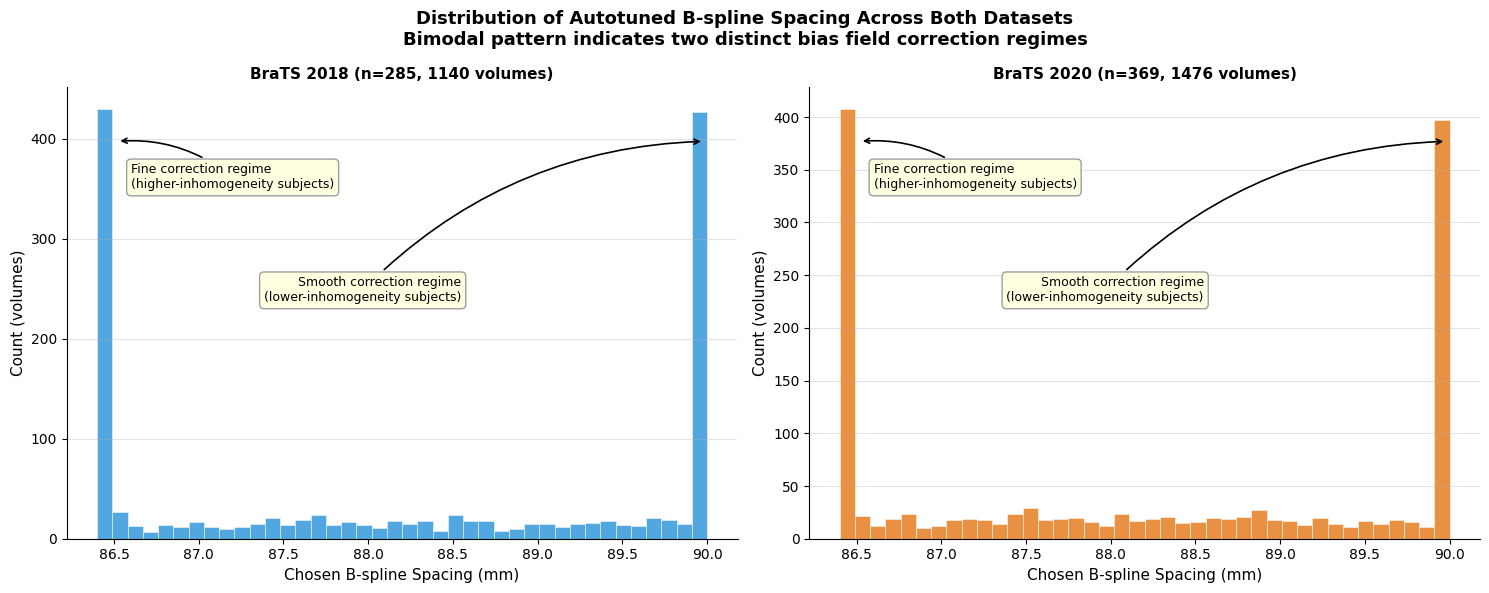

Saved.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


df18 = pd.read_csv(r"C:\content\BRAIN2018\AutoTuned_N4_Brats2018\figures\per_scan_table.csv")
df20 = pd.read_csv(r"C:\content\BRAIN2020\AutoTuned_N4_Brast2020\figures\per_scan_table.csv")
bspline_18 = df18["bspline_mm"].values
bspline_20 = df20["bspline_mm"].values

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
fig.suptitle(
    "Distribution of Autotuned B-spline Spacing Across Both Datasets\n"
    "Bimodal pattern indicates two distinct bias field correction regimes",
    fontsize=13, fontweight="bold"
)

datasets = [
    (axes[0], bspline_18, "BraTS 2018 (n=285, 1140 volumes)", "#3498DB"),
    (axes[1], bspline_20, "BraTS 2020 (n=369, 1476 volumes)", "#E67E22"),
]

for ax, bspline_vals, title, color in datasets:
    ax.hist(bspline_vals, bins=40, color=color,
            edgecolor="white", linewidth=0.4, alpha=0.85)

    y_max = ax.get_ylim()[1]

    ax.annotate(
        "Fine correction regime\n(higher-inhomogeneity subjects)",
        xy=(86.52, y_max * 0.88), 
        xytext=(86.6, y_max * 0.80), 
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=1.2,
            connectionstyle="arc3,rad=0.2"
        ),
        fontsize=9, ha="left", va="center",
        bbox=dict(boxstyle="round,pad=0.35", fc="lightyellow",
                  ec="#999999", alpha=0.95)
    )


    ax.annotate(
        "Smooth correction regime\n(lower-inhomogeneity subjects)",
        xy=(89.98, y_max * 0.88), 
        xytext=(88.55, y_max * 0.55), 
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=1.2,
            connectionstyle="arc3,rad=-0.2"
        ),
        fontsize=9, ha="right", va="center",
        bbox=dict(boxstyle="round,pad=0.35", fc="lightyellow",
                  ec="#999999", alpha=0.95)
    )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Chosen B-spline Spacing (mm)", fontsize=11)
    ax.set_ylabel("Count (volumes)", fontsize=11)
    ax.grid(axis="y", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("bspline_bimodal_both_datasets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

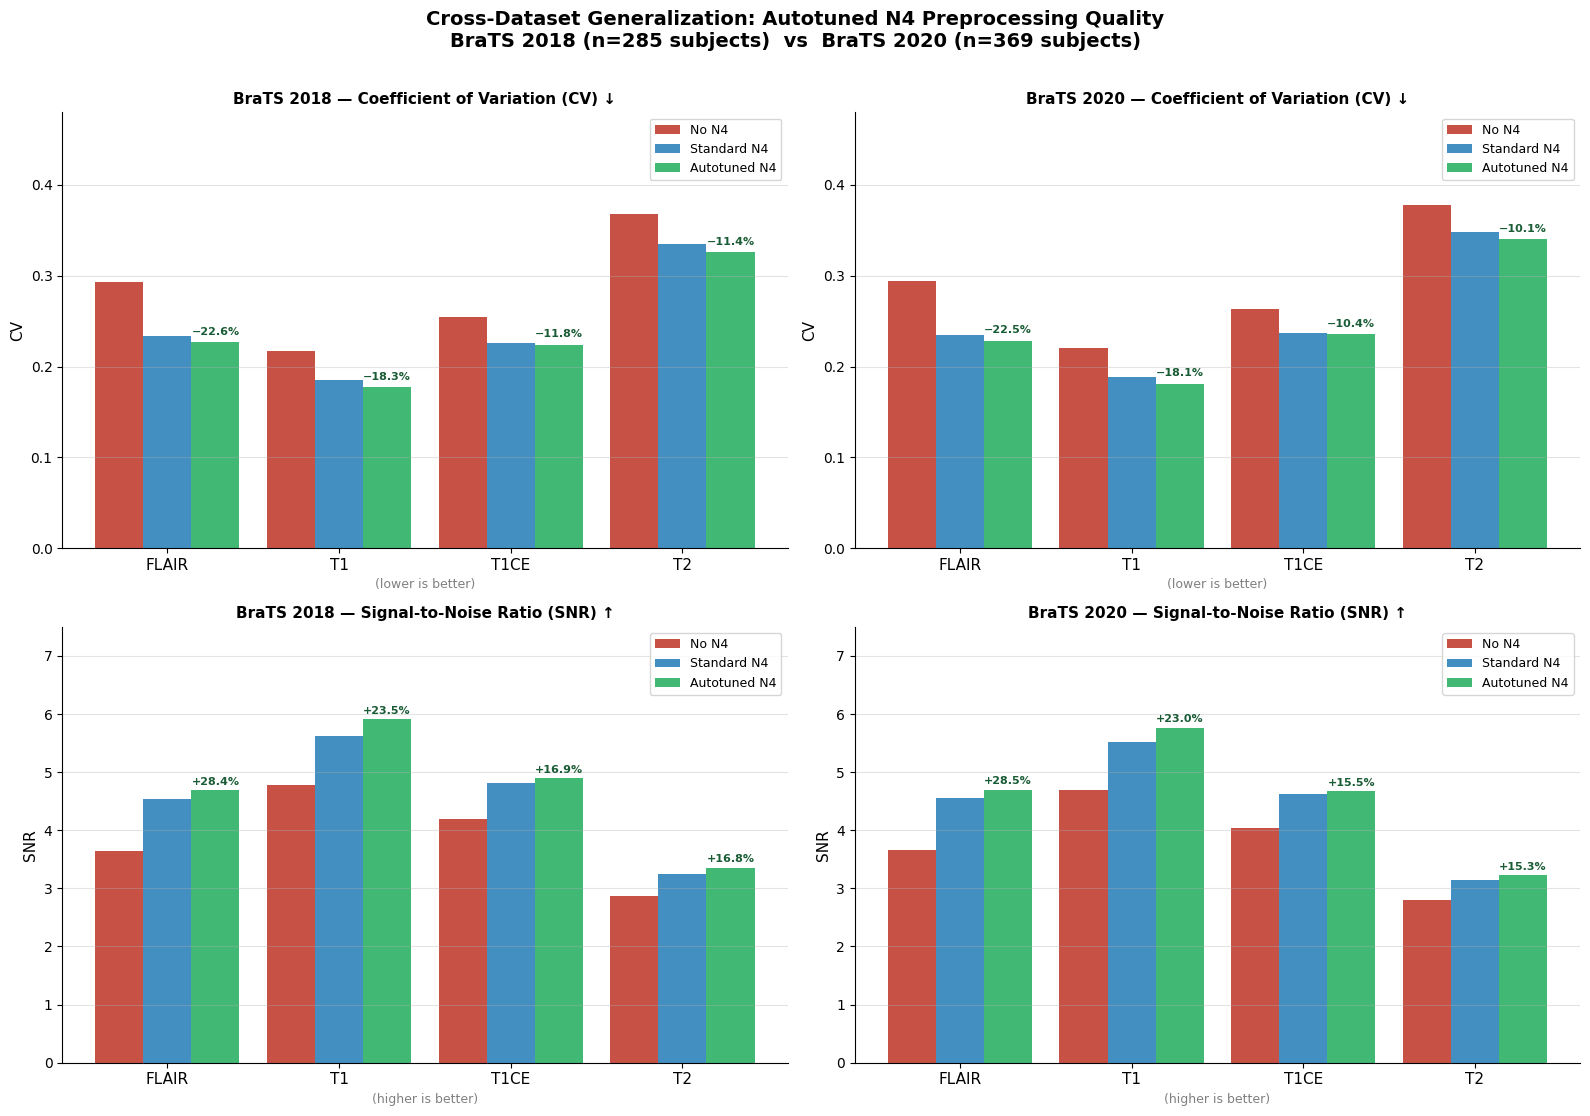

Saved.


In [2]:
import numpy as np
import matplotlib.pyplot as plt


modalities = ["FLAIR", "T1", "T1CE", "T2"]
x = np.arange(len(modalities))
w = 0.28


cv18_raw  = [0.2927, 0.2169, 0.2543, 0.3681]
cv18_std  = [0.2340, 0.1849, 0.2262, 0.3353]
cv18_auto = [0.2266, 0.1771, 0.2242, 0.3261]
snr18_raw  = [3.651, 4.783, 4.188, 2.871]
snr18_std  = [4.540, 5.629, 4.819, 3.242]
snr18_auto = [4.687, 5.907, 4.896, 3.353]


cv20_raw  = [0.2946, 0.2209, 0.2629, 0.3784]
cv20_std  = [0.2347, 0.1884, 0.2365, 0.3478]
cv20_auto = [0.2283, 0.1810, 0.2355, 0.3401]
snr20_raw  = [3.656, 4.687, 4.046, 2.802]
snr20_std  = [4.559, 5.516, 4.622, 3.138]
snr20_auto = [4.697, 5.767, 4.672, 3.230]

C_RAW  = "#C0392B" 
C_STD  = "#2980B9"
C_AUTO = "#27AE60" 

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "Cross-Dataset Generalization: Autotuned N4 Preprocessing Quality\n"
    "BraTS 2018 (n=285 subjects)  vs  BraTS 2020 (n=369 subjects)",
    fontsize=14, fontweight="bold", y=1.01
)

datasets = [
    ("BraTS 2018", cv18_raw, cv18_std, cv18_auto,
                   snr18_raw, snr18_std, snr18_auto),
    ("BraTS 2020", cv20_raw, cv20_std, cv20_auto,
                   snr20_raw, snr20_std, snr20_auto),
]

for col, (ds_name, cv_r, cv_s, cv_a,
                    snr_r, snr_s, snr_a) in enumerate(datasets):


    ax = axes[0, col]
    ax.bar(x - w, cv_r, w, label="No N4",        color=C_RAW,  alpha=0.88)
    ax.bar(x,     cv_s, w, label="Standard N4",  color=C_STD,  alpha=0.88)
    ax.bar(x + w, cv_a, w, label="Autotuned N4", color=C_AUTO, alpha=0.88)


    for i in range(len(modalities)):
        pct = (cv_r[i] - cv_a[i]) / cv_r[i] * 100
        ax.text(x[i] + w, cv_a[i] + 0.006,
                f"−{pct:.1f}%", ha="center", va="bottom",
                fontsize=8, color="#1A5C35", fontweight="bold")

    ax.set_title(f"{ds_name} — Coefficient of Variation (CV) ↓",
                 fontsize=11, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(modalities, fontsize=11)
    ax.set_ylabel("CV", fontsize=11)
    ax.set_ylim(0, 0.48)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.35)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_xlabel("(lower is better)", fontsize=9, color="gray")

 
    ax = axes[1, col]
    ax.bar(x - w, snr_r, w, label="No N4",        color=C_RAW,  alpha=0.88)
    ax.bar(x,     snr_s, w, label="Standard N4",  color=C_STD,  alpha=0.88)
    ax.bar(x + w, snr_a, w, label="Autotuned N4", color=C_AUTO, alpha=0.88)

    for i in range(len(modalities)):
        pct = (snr_a[i] - snr_r[i]) / snr_r[i] * 100
        ax.text(x[i] + w, snr_a[i] + 0.06,
                f"+{pct:.1f}%", ha="center", va="bottom",
                fontsize=8, color="#1A5C35", fontweight="bold")

    ax.set_title(f"{ds_name} — Signal-to-Noise Ratio (SNR) ↑",
                 fontsize=11, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(modalities, fontsize=11)
    ax.set_ylabel("SNR", fontsize=11)
    ax.set_ylim(0, 7.5)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.35)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_xlabel("(higher is better)", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("cross_dataset_generalization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")